### Project Title :Time Series Forecasting for Energy Consumtion


#### Objective : Using Machine Learning to Forecast Energy Consumption




<img src = "https://res.cloudinary.com/monday-blogs/w_768,h_384,c_fit/fl_lossy,f_auto,q_auto/wp-blog/2021/05/sales-forecasting-software.jpg">

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

In [4]:
df = pd.read_csv('/content/PJME_hourly.csv')
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)

In [18]:
df.head()

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,prediction
Datetime,,,,,,,,,,
2002-12-31 01:00:00,26498.0,1,1,4,12,2002,365,31,1,NaN
2002-12-31 02:00:00,25147.0,2,1,4,12,2002,365,31,1,NaN
2002-12-31 03:00:00,24574.0,3,1,4,12,2002,365,31,1,NaN
2002-12-31 04:00:00,24393.0,4,1,4,12,2002,365,31,1,NaN
2002-12-31 05:00:00,24860.0,5,1,4,12,2002,365,31,1,NaN


#### data cleaning
process for dATA cleaning
looking for duplicates and remove them

standardization

deal with null and empty values

remove unwanted columns


In [26]:
df.duplicated().sum()

np.int64(6)

In [27]:
df.isnull().sum()


,0
PJME_MW,0
hour,0
dayofweek,0
quarter,0
month,0
year,0
dayofyear,0
dayofmonth,0
weekofyear,0
prediction,113926


In [19]:
df.columns

Index(['PJME_MW', 'hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear', 'prediction'],
      dtype='object')

In [29]:
### accessing unwanted columns
df[['dayofweek','year','prediction']]

,dayofweek,year,prediction
Datetime,,,
2002-12-31 01:00:00,1,2002,NaN
2002-12-31 02:00:00,1,2002,NaN
2002-12-31 03:00:00,1,2002,NaN
2002-12-31 04:00:00,1,2002,NaN
2002-12-31 05:00:00,1,2002,NaN
...,...,...,...
2018-01-01 20:00:00,0,2018,36147.902344
2018-01-01 21:00:00,0,2018,36096.609375
2018-01-01 22:00:00,0,2018,34596.582031


In [24]:
len(df)

145372

In [20]:
df.shape

(145372, 10)

In [30]:
df.drop(columns='month',inplace=True)

In [31]:
df.columns

Index(['PJME_MW', 'hour', 'dayofweek', 'quarter', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear', 'prediction'],
      dtype='object')

In [32]:
df.describe()

,PJME_MW,hour,dayofweek,quarter,year,dayofyear,dayofmonth,weekofyear,prediction
count,145372.000000,145372.000000,145372.000000,145372.000000,145372.000000,145372.000000,145372.000000,145372.0,31446.000000
mean,32079.773264,11.501204,2.999126,2.481303,2009.801282,180.464656,15.722677,26.219334,31722.462891
std,6464.257970,6.921921,1.999554,1.114443,4.791893,105.138281,8.801362,15.019843,5193.676758
min,14544.000000,0.000000,0.000000,1.000000,2002.000000,1.000000,1.000000,1.0,21116.724609
25%,27573.000000,6.000000,1.000000,1.000000,2006.000000,90.000000,8.000000,13.0,27759.156250
50%,31421.000000,12.000000,3.000000,2.000000,2010.000000,179.000000,16.000000,26.0,31525.490234
75%,35649.250000,18.000000,5.000000,3.000000,2014.000000,271.000000,23.000000,39.0,35471.503906
max,62009.000000,23.000000,6.000000,4.000000,2018.000000,366.000000,31.000000,53.0,44193.800781


In [33]:
df.iloc[0,2]

np.int32(1)

In [34]:
##slicing
df.iloc[0,0:3]

,2002-12-31 01:00:00
PJME_MW,26498.0
hour,1.0
dayofweek,1.0


In [23]:
df.tail()

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,prediction
Datetime,,,,,,,,,,
2018-01-01 20:00:00,44284.0,20,0,1,1,2018,1,1,1,36147.902344
2018-01-01 21:00:00,43751.0,21,0,1,1,2018,1,1,1,36096.609375
2018-01-01 22:00:00,42402.0,22,0,1,1,2018,1,1,1,34596.582031
2018-01-01 23:00:00,40164.0,23,0,1,1,2018,1,1,1,32338.955078
2018-01-02 00:00:00,38608.0,0,1,1,1,2018,2,2,1,31227.607422


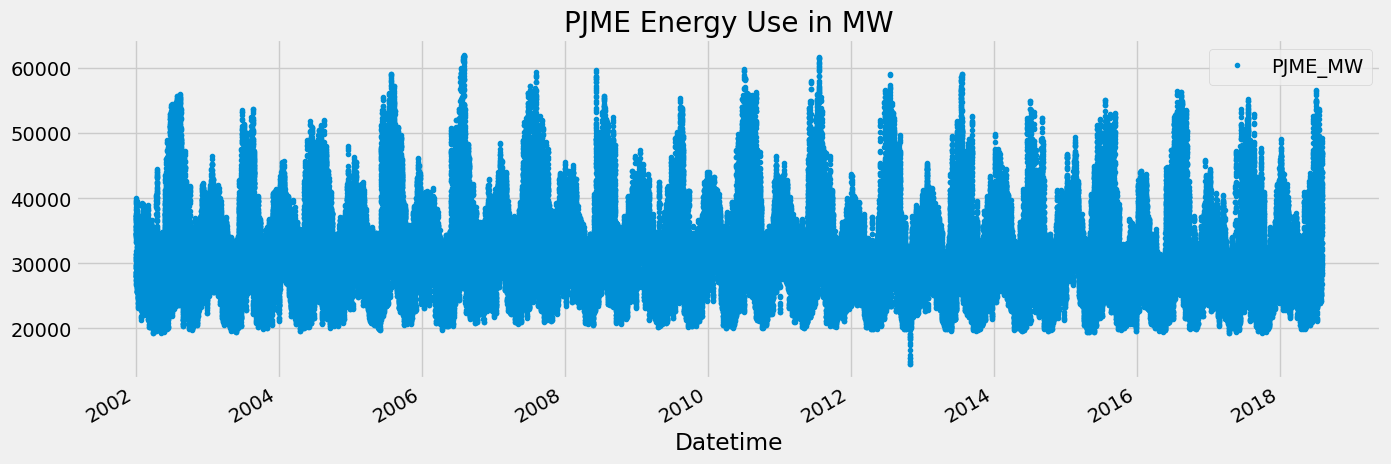

In [5]:
df.plot(style='.',
        figsize=(15, 5),
        color=color_pal[0],
        title='PJME Energy Use in MW')
plt.show()

Train and Test

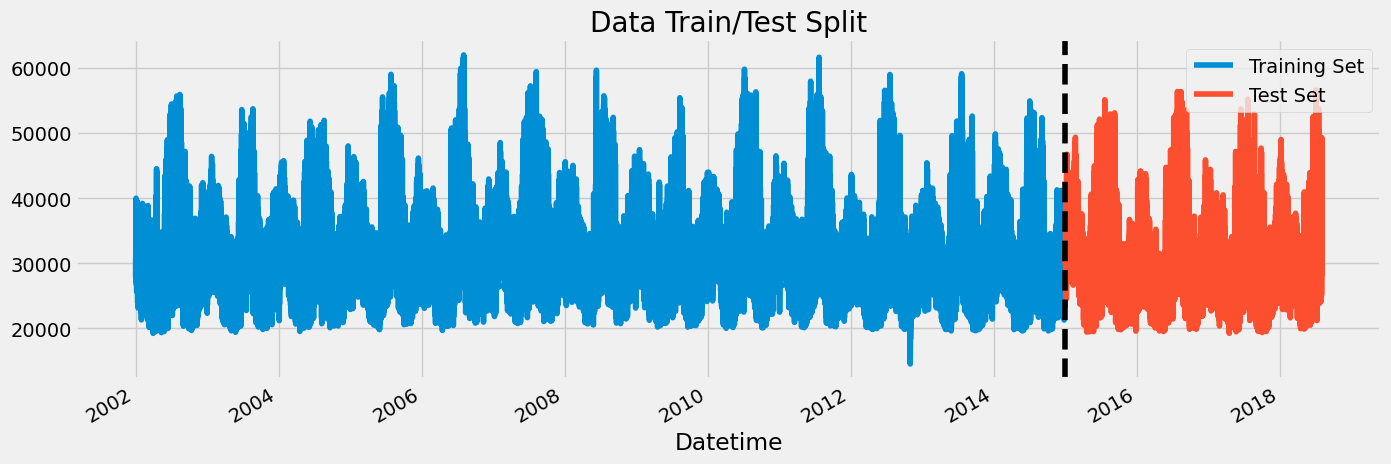

In [6]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

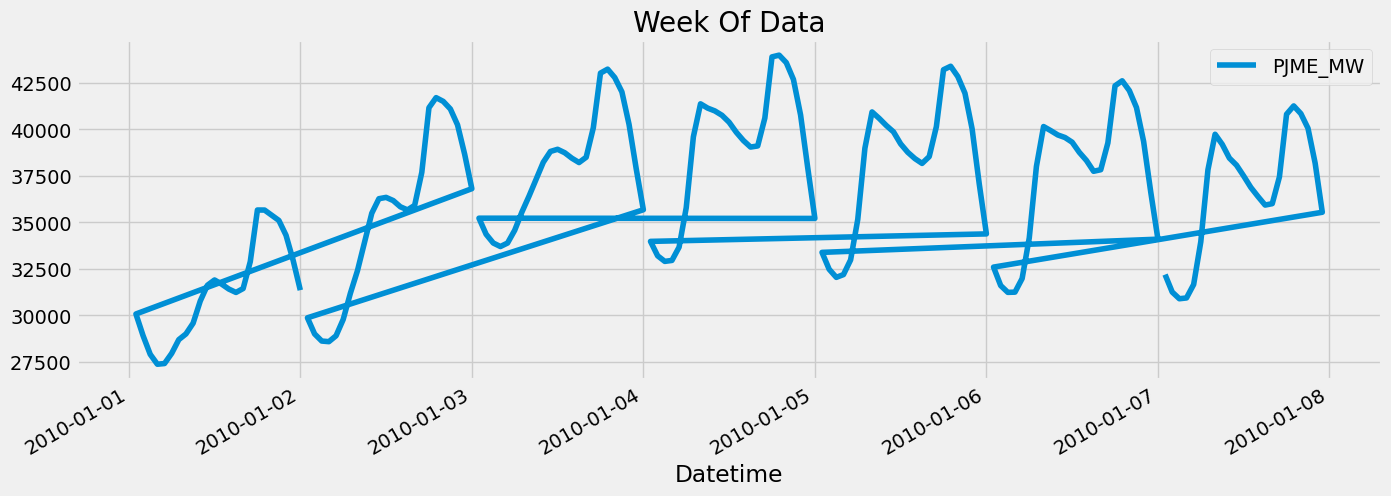

In [7]:
df.loc[(df.index > '01-01-2010') & (df.index < '01-08-2010')] \
    .plot(figsize=(15, 5), title='Week Of Data')
plt.show()

Feature Creation¶

In [8]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

Visualize our Feature / Target Relationship

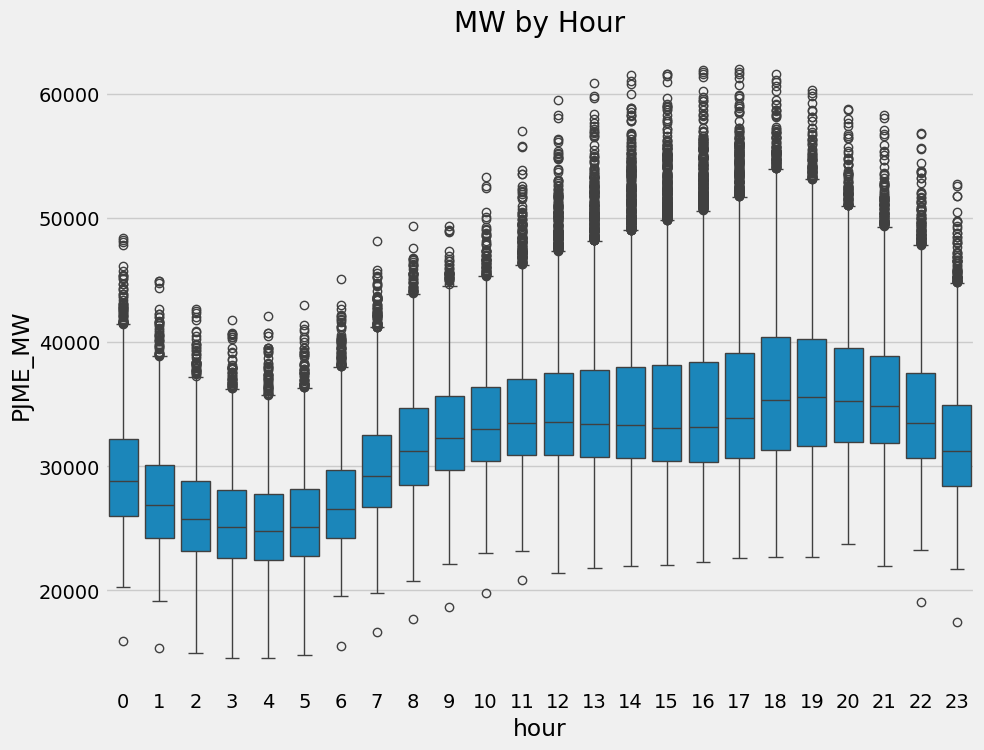

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='hour', y='PJME_MW')
ax.set_title('MW by Hour')
plt.show()


/tmp/ipykernel_940/1150946640.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='PJME_MW', palette='Blues')


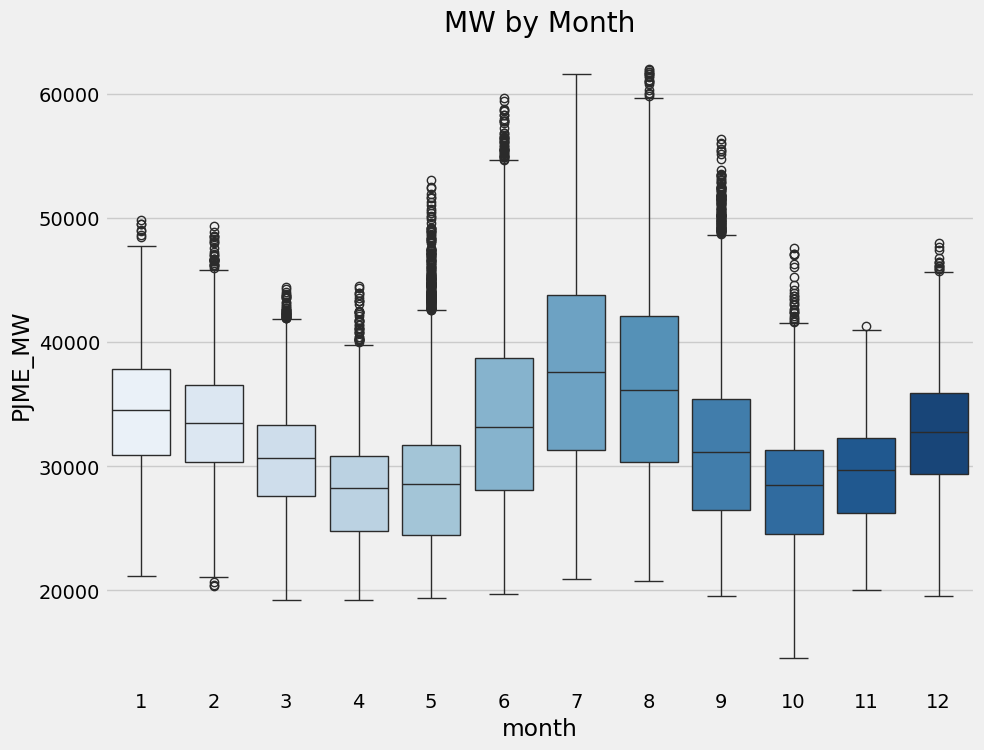

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='month', y='PJME_MW', palette='Blues')
ax.set_title('MW by Month')
plt.show()


#### Creating our model

In [11]:
train = create_features(train)
test = create_features(test)

FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year']
TARGET = 'PJME_MW'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [12]:
reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)
reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:32605.13605	validation_1-rmse:31657.15764


/usr/local/lib/python3.13/dist-packages/xgboost/callback.py:385: UserWarning: [05:17:27] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12584.38995	validation_1-rmse:11748.11856
[200]	validation_0-rmse:5836.77160	validation_1-rmse:5367.04436
[300]	validation_0-rmse:3926.66202	validation_1-rmse:4028.95967
[400]	validation_0-rmse:3448.41148	validation_1-rmse:3856.69750
[500]	validation_0-rmse:3287.85961	validation_1-rmse:3810.57566
[600]	validation_0-rmse:3205.22683	validation_1-rmse:3774.69216
[700]	validation_0-rmse:3150.34169	validation_1-rmse:3757.05520
[800]	validation_0-rmse:3110.70530	validation_1-rmse:3740.45591
[900]	validation_0-rmse:3080.90763	validation_1-rmse:3730.04135
[999]	validation_0-rmse:3054.21334	validation_1-rmse:3726.61186


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

Feature Importance

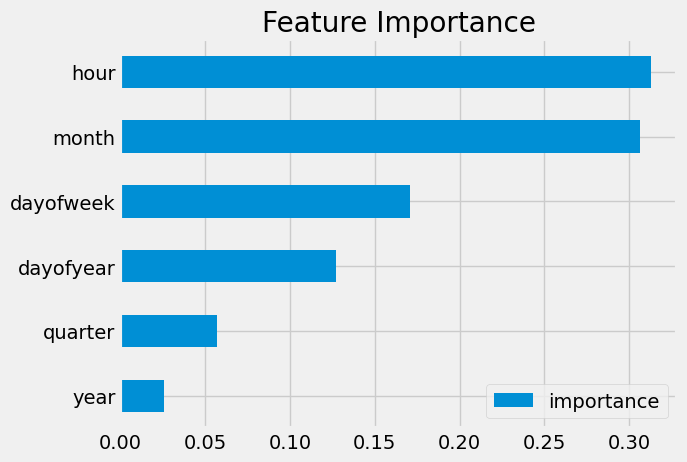

In [13]:
fi = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

#### Forecast on Test

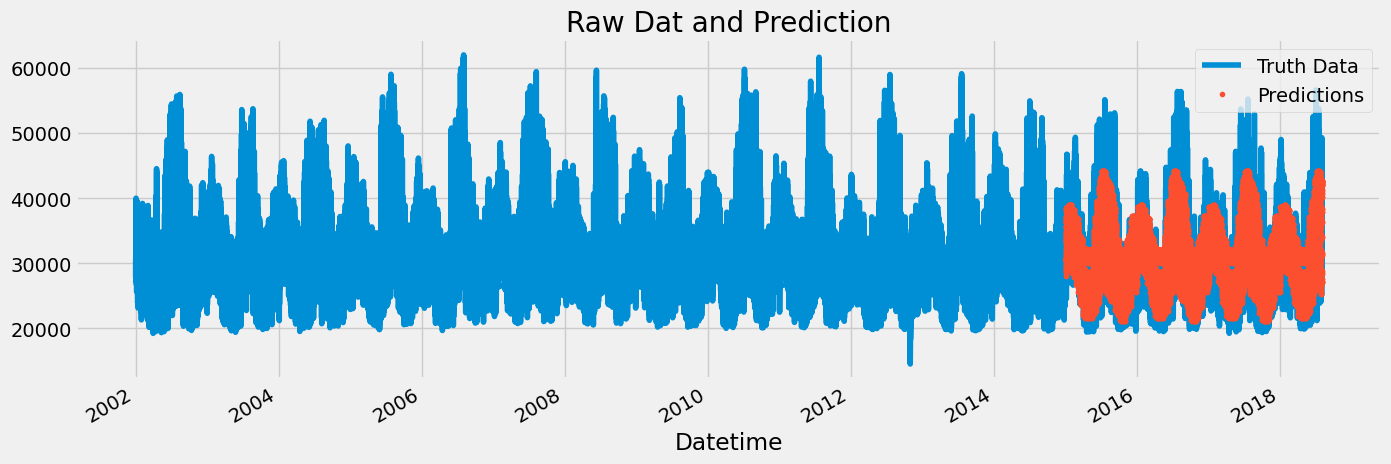

In [14]:
test['prediction'] = reg.predict(X_test)
df = df.merge(test[['prediction']], how='left', left_index=True, right_index=True)
ax = df[['PJME_MW']].plot(figsize=(15, 5))
df['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Dat and Prediction')
plt.show()

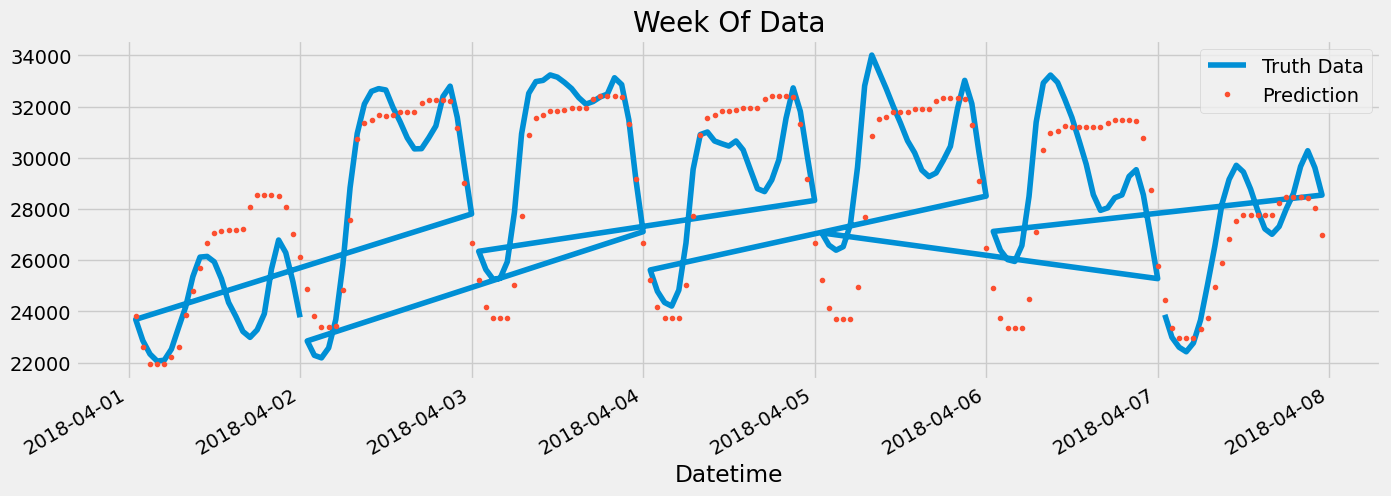

In [15]:
ax = df.loc[(df.index > '04-01-2018') & (df.index < '04-08-2018')]['PJME_MW'] \
    .plot(figsize=(15, 5), title='Week Of Data')
df.loc[(df.index > '04-01-2018') & (df.index < '04-08-2018')]['prediction'] \
    .plot(style='.')
plt.legend(['Truth Data','Prediction'])
plt.show()

#### Score (RMSE)

In [16]:
score = np.sqrt(mean_squared_error(test['PJME_MW'], test['prediction']))
print(f'RMSE Score on Test set: {score:0.2f}')

RMSE Score on Test set: 3726.50


#### Calculate Error¶
Look at the worst and best predicted days

In [17]:
test['error'] = np.abs(test[TARGET] - test['prediction'])
test['date'] = test.index.date
test.groupby(['date'])['error'].mean().sort_values(ascending=False).head(10)

,error
date,
2016-08-13,12792.355794
2016-08-14,12755.737467
2016-09-10,12165.990804
2015-02-20,11041.841146
2016-09-09,10840.006429
2018-01-06,10523.503174
2016-08-12,10035.958171
2015-02-21,9967.257812
2015-02-16,9834.920573


#### Next Steps¶
More robust cross validation
Add more features (weather forecast, holidays)

The End